In [1]:
import anndata as ad
import decoupler as dc
#import mofax as mfx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import statsmodels.stats.multitest as multitest
import re

def limpiar_nombre(nombre):
    # Eliminar contenido entre paréntesis
    nombre = re.sub(r'\s*\(.*?\)', '', nombre)
    # Reemplazar guiones bajos por espacios
    nombre = nombre.replace('_', ' ')
    # Limpiar espacios extra
    nombre = nombre.strip().upper()
    return nombre

## Encontrar factores significativos para los TFs de YAP/TAZ y las top 10 drogas del extremo positivo y negativo

In [5]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# --- 1. Factores significativos ---
PATH_ADATA = "/home/miguel-agromayor-otero/Escritorio/TFM_datos/mofa_adata_30f.h5ad"
df = pd.read_parquet('/home/miguel-agromayor-otero/Escritorio/TFM_datos/lfc_yap')
adata = ad.read_h5ad(PATH_ADATA)
factors = adata.uns["mofa_weights_factors"]
collectri = dc.get_collectri(organism="human")
tfs_of_interes = ["YAP1", "TEAD1", "TEAD2", "TEAD4", "WWTR1"]

W = pd.DataFrame(
    adata.uns["mofa_weights"],
    index=adata.uns["mofa_weights_genes"],
    columns=factors
)
acts, pvals = dc.run_ulm(W.T, net=collectri, source="source", target="target", weight="weight")
acts_sig = acts.where((pvals < 0.05))
resultados = acts_sig[tfs_of_interes].dropna(how='all')
print(resultados)
# --- 2. Scores y top/bottom por factor ---
scores = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
scores['drug'] = adata.obs['drug']
scores_avg = scores.groupby('drug')[factors].mean()

# Observo si existe diferencias significativas entre los fármacos  de los dos extremos de los factores miro que drogas están en el top y en el bottom de cada factor para luego mirar que fármacos son las que presentan un lfc más negativo que son los fármacos  que me interesarían
top_bottom = {}
for factor in resultados.index:
    tfs_sig = resultados.loc[factor].dropna().index.tolist()
    top_bottom[factor] = {
        'top': scores_avg[factor].nlargest(10).index.tolist(),
        'bottom': scores_avg[factor].nsmallest(10).index.tolist(),
        'tfs': tfs_sig
    }

# --- 3. Aqui comparo los fármacos del extremo positivo y negativo de cada factor a partir de su lfc para observar si existen diferencias significativas
stats_list = []
for fac, groups in top_bottom.items():
    for tf in groups["tfs"]:
        v_top = df[(df["drug"].isin(groups["top"])) & (df["feature"] == tf)]["value"]
        v_bot = df[(df["drug"].isin(groups["bottom"])) & (df["feature"] == tf)]["value"]
        if len(v_top) > 0 and len(v_bot) > 0:
            stat, p = ttest_ind(v_top, v_bot, equal_var=False)
            stats_list.append({
                "factor": fac, "TF": tf,
                "mean_top": v_top.mean(), "mean_bot": v_bot.mean(),
                "median_top": v_top.median(), "median_bot": v_bot.median(),
                "t_stat": stat, "pval": p
            })

df_stats = pd.DataFrame(stats_list)
df_stats["padj"] = multipletests(df_stats["pval"], method="fdr_bh")[1]
df_stats["diff_mean"] = df_stats["mean_top"] - df_stats["mean_bot"]

# --- Clasifico cada par factor-TF según el signo de su actividad ULM,
# para saber qué lado del score de factor corresponde al fenotipo de interés
factors_pos = {}
factors_neg = {}
for factor in top_bottom.keys():
    for tf in top_bottom[factor]["tfs"]:
        act_val = resultados.loc[factor, tf]
        if act_val > 0:
            factors_pos.setdefault(factor, []).append(tf)
        else:
            factors_neg.setdefault(factor, []).append(tf)
            
# --- 4b. Promedio el LFC por fármaco y TF (colapsando réplicas), 
# para usarlo como dato de entrada en las gráficas de boxplot
df_avg = df.groupby(["drug", "feature"])["value"].mean().reset_index()


              YAP1     TEAD1     TEAD2     TEAD4     WWTR1
Factor3        NaN       NaN -2.103731       NaN       NaN
Factor5  -2.626870 -4.584037       NaN       NaN -2.204798
Factor6        NaN       NaN -2.927429       NaN       NaN
Factor8        NaN       NaN -2.049571       NaN       NaN
Factor10       NaN  2.700799       NaN       NaN       NaN
Factor11       NaN       NaN       NaN  2.602720       NaN
Factor13  2.118151       NaN       NaN       NaN       NaN
Factor14  4.354217       NaN       NaN       NaN  1.988545
Factor18  2.279089       NaN       NaN       NaN       NaN
Factor19       NaN       NaN       NaN       NaN  2.724448
Factor21  3.098131       NaN       NaN       NaN       NaN
Factor24       NaN       NaN       NaN  2.206887       NaN
Factor25 -2.060553       NaN       NaN       NaN  2.494527
Factor27       NaN       NaN       NaN       NaN -2.165344
Factor28       NaN  2.896006       NaN       NaN       NaN


/tmp/ipykernel_539320/4087836257.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scores_avg = scores.groupby('drug')[factors].mean()


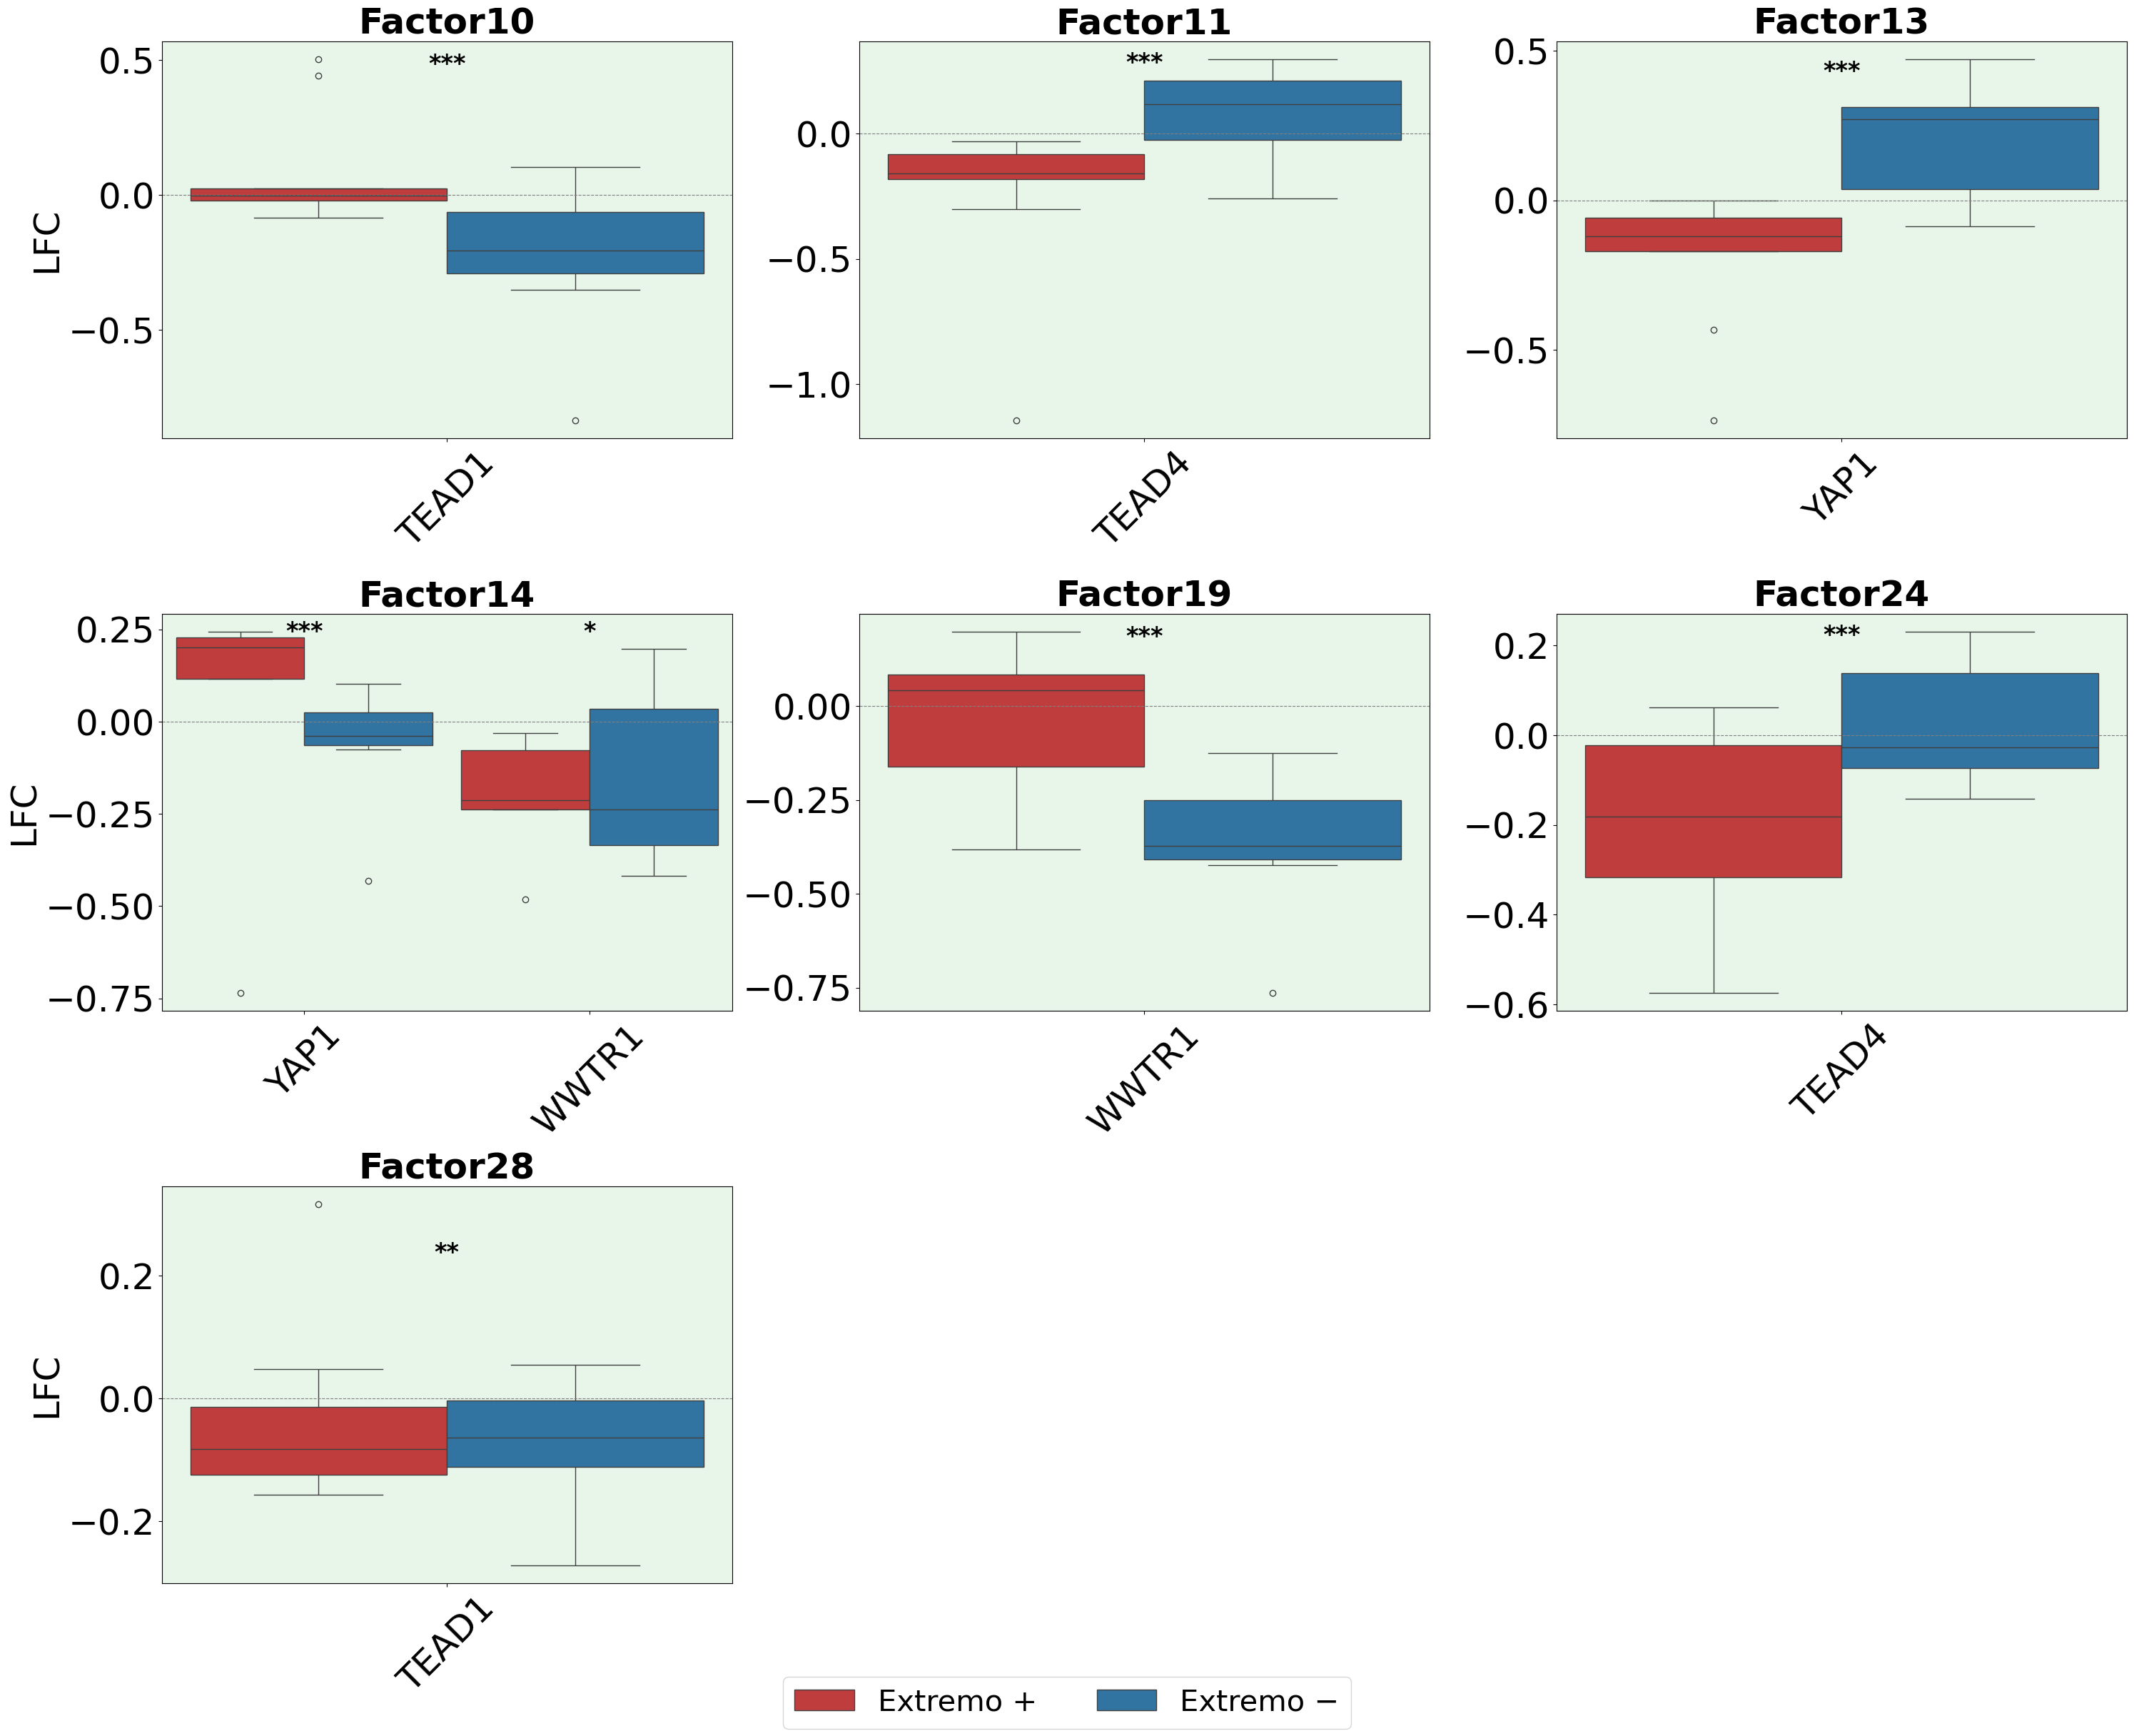

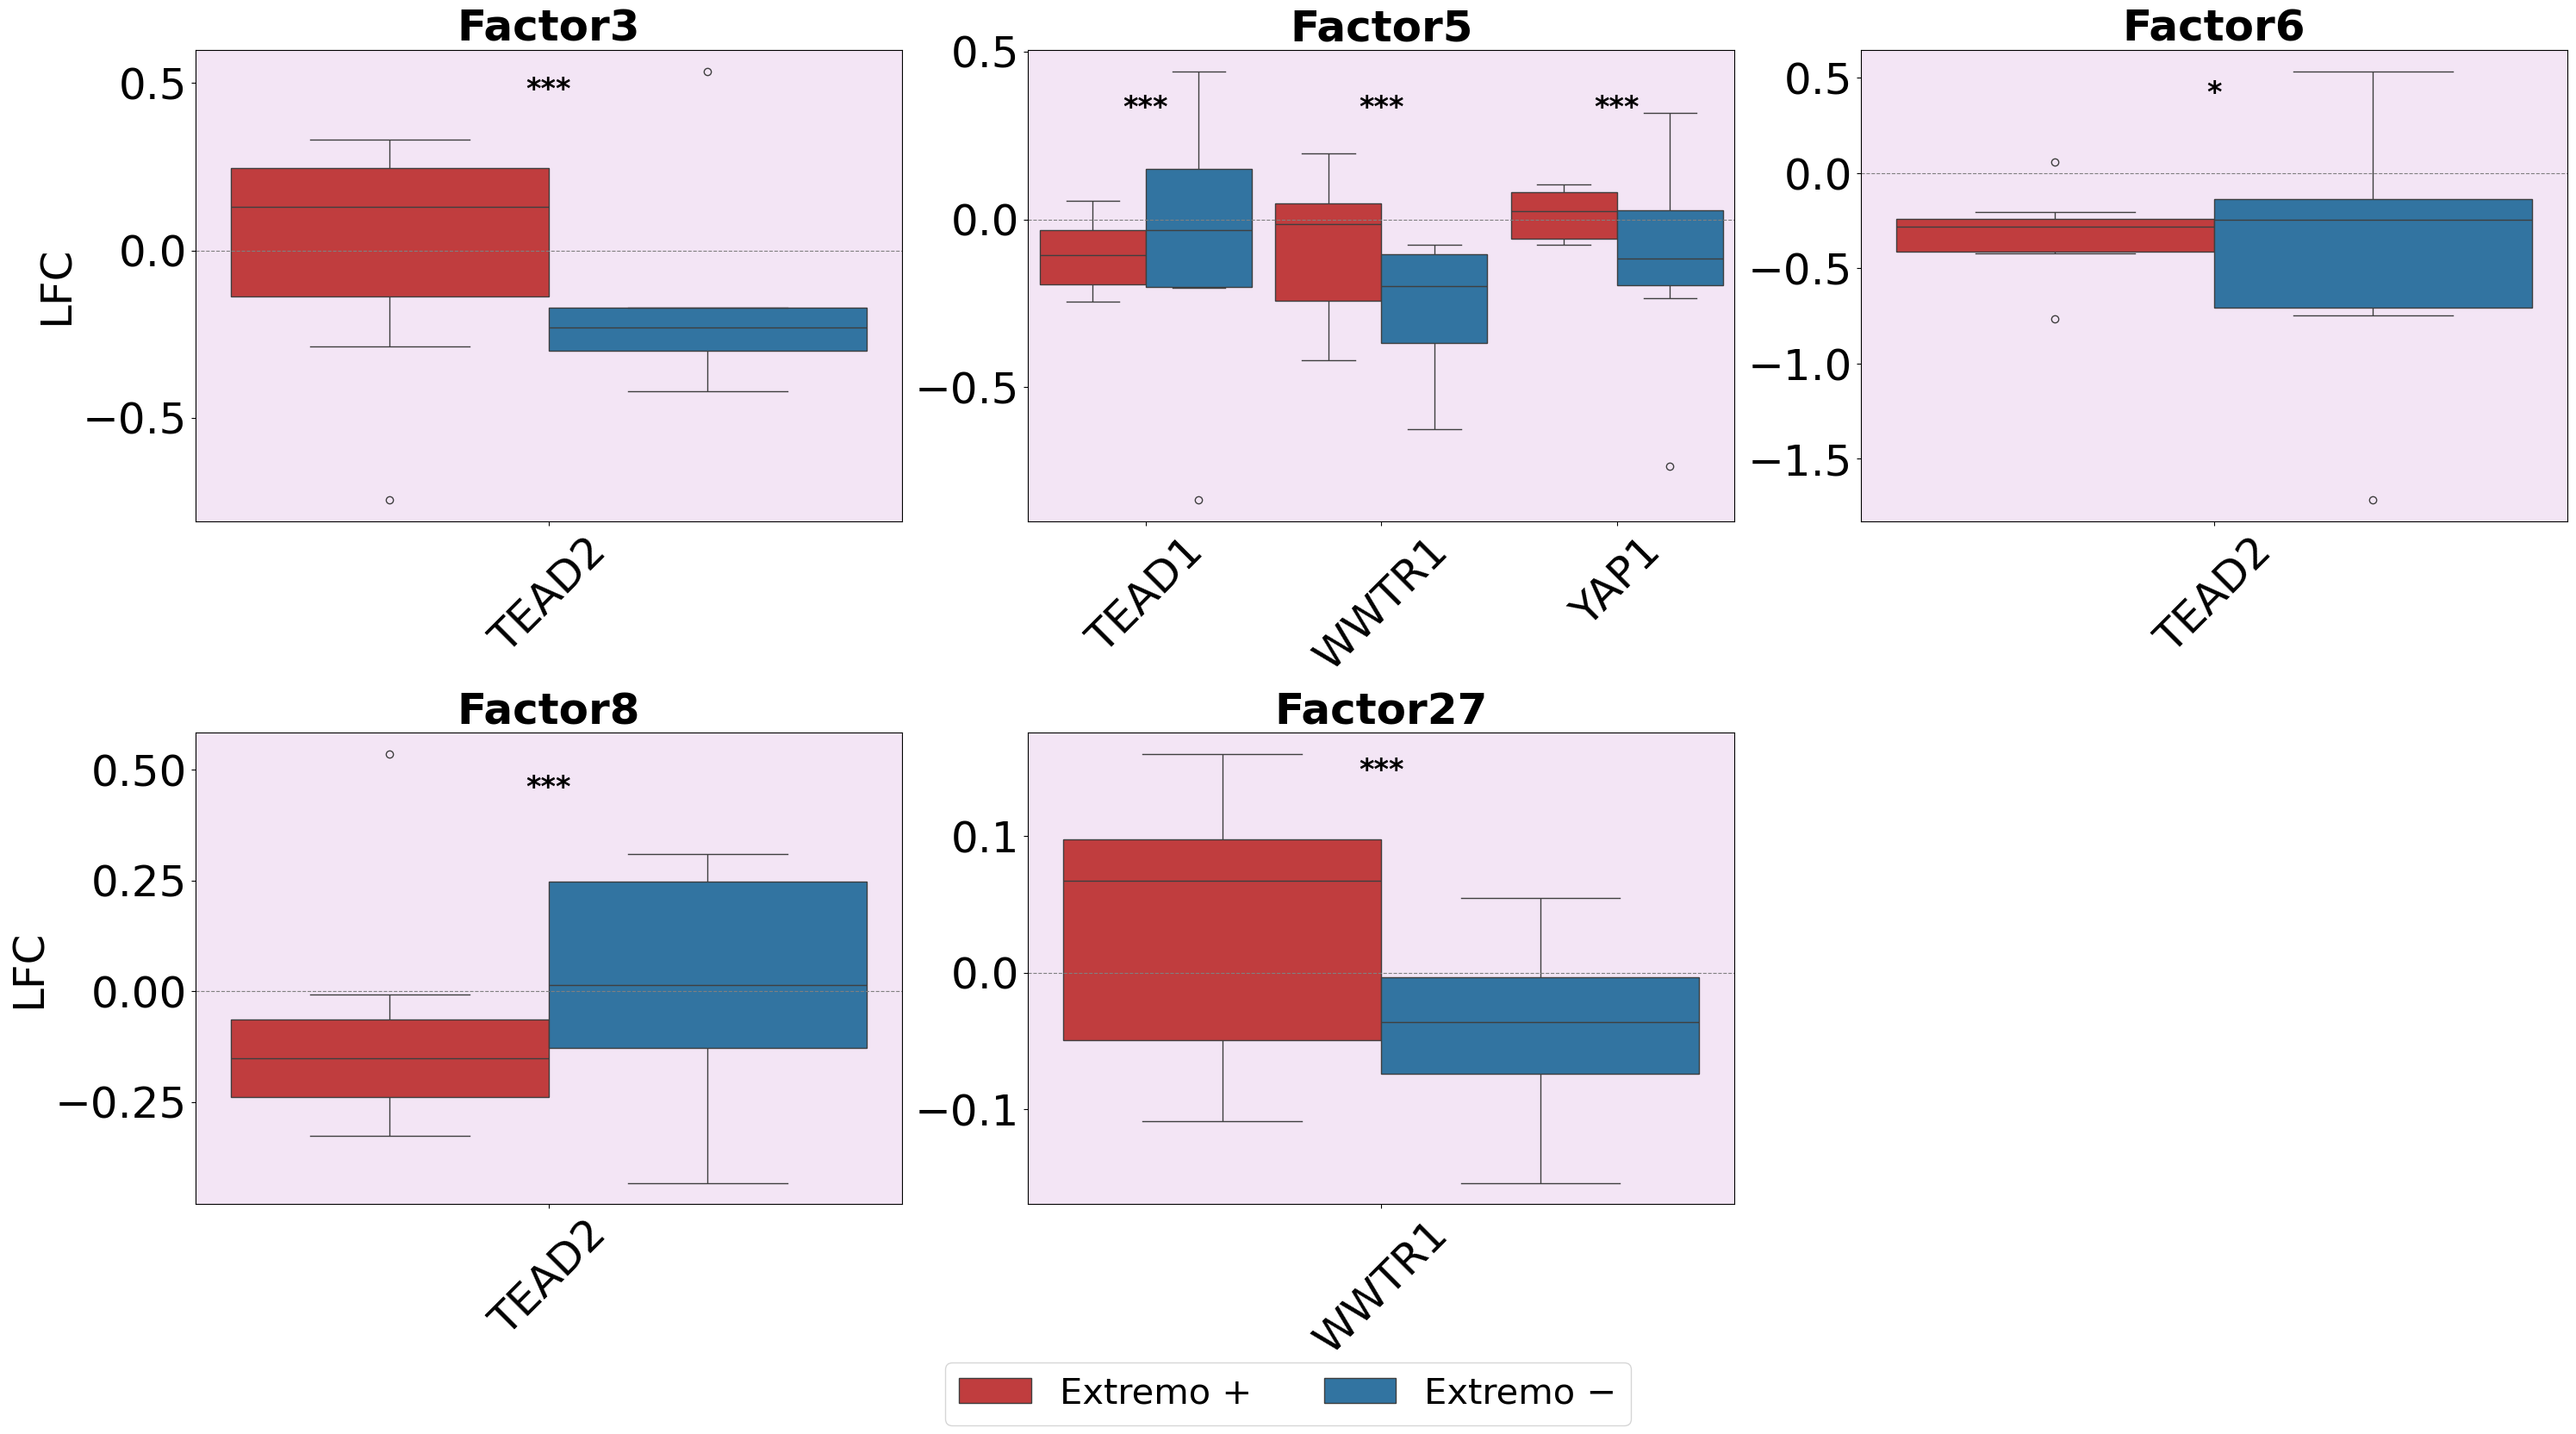

In [6]:
# Panel positivo
# Filtrar solo factores con al menos un TF significativo
pos_factors_sig = {}
for factor, tfs in factors_pos.items():
    tfs_sig = []
    for tf in tfs:
        r = df_stats[(df_stats["factor"] == factor) & (df_stats["TF"] == tf)]
        if len(r) > 0 and r["padj"].values[0] < 0.05:
            tfs_sig.append(tf)
    if tfs_sig:
        pos_factors_sig[factor] = tfs_sig

n = len(pos_factors_sig)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 8 * nrows))
axes_flat = list(axes.flat) if n > 1 else [axes]

for i, (factor, tfs_panel) in enumerate(pos_factors_sig.items()):
    ax = axes_flat[i]
    groups = top_bottom[factor]
    df_f = pd.concat([
        df_avg[df_avg["drug"].isin(groups["top"]) & df_avg["feature"].isin(tfs_panel)].assign(group="Extremo +"),
        df_avg[df_avg["drug"].isin(groups["bottom"]) & df_avg["feature"].isin(tfs_panel)].assign(group="Extremo −")
    ])
    ax.set_facecolor("#e8f5e9")
    sns.boxplot(data=df_f, x="feature", y="value", hue="group",
                palette={"Extremo +": "#d62728", "Extremo −": "#1f77b4"},
                order=tfs_panel, 
                width=0.9, ax=ax)
    ax.axhline(0, ls="--", color="grey", lw=0.8)
    ax.set_title(factor, fontsize=36, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("LFC" if i % ncols == 0 else "", fontsize=36)
    ax.tick_params(axis="x", rotation=45, labelsize=36)
    ax.tick_params(axis="y", labelsize=36)

    y_max = df_f["value"].quantile(0.98)
    for j, tf in enumerate(tfs_panel):
        r = df_stats[(df_stats["factor"] == factor) & (df_stats["TF"] == tf)]
        p = r["padj"].values[0]
        label = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else None
        if label:
            ax.text(j, y_max * 0.95, label, ha="center", fontsize=24, fontweight="bold")

    if ax.get_legend():
        ax.get_legend().remove()

for k in range(n, nrows * ncols):
    axes_flat[k].set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=30,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('/home/miguel-agromayor-otero/Escritorio/TFM_datos/Graficos/boxplots_yaptaz_positiva.pdf',
            format='pdf', bbox_inches='tight')
plt.show()


# Panel negativo
neg_factors_sig = {}
for factor, tfs in factors_neg.items():
    tfs_sig = []
    for tf in tfs:
        r = df_stats[(df_stats["factor"] == factor) & (df_stats["TF"] == tf)]
        if len(r) > 0 and r["padj"].values[0] < 0.05:
            tfs_sig.append(tf)
    if tfs_sig:
        neg_factors_sig[factor] = tfs_sig

n = len(neg_factors_sig)
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 8 * nrows))
axes_flat = list(axes.flat) if n > 1 else [axes]

for i, (factor, tfs_panel) in enumerate(neg_factors_sig.items()):
    ax = axes_flat[i]
    groups = top_bottom[factor]
    df_f = pd.concat([
        df_avg[df_avg["drug"].isin(groups["top"]) & df_avg["feature"].isin(tfs_panel)].assign(group="Extremo +"),
        df_avg[df_avg["drug"].isin(groups["bottom"]) & df_avg["feature"].isin(tfs_panel)].assign(group="Extremo −")
    ])
    ax.set_facecolor("#f3e5f5")
    sns.boxplot(data=df_f, x="feature", y="value", hue="group",
                palette={"Extremo +": "#d62728", "Extremo −": "#1f77b4"},
                width=0.9, ax=ax)
    ax.axhline(0, ls="--", color="grey", lw=0.8)
    ax.set_title(factor, fontsize=36, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("LFC" if i % ncols == 0 else "", fontsize=36)
    ax.tick_params(axis="x", rotation=45, labelsize=36)
    ax.tick_params(axis="y", labelsize=36)

    y_max = df_f["value"].quantile(0.98)
    for j, tf in enumerate(tfs_panel):
        r = df_stats[(df_stats["factor"] == factor) & (df_stats["TF"] == tf)]
        p = r["padj"].values[0]
        label = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else None
        if label:
            ax.text(j, y_max * 0.95, label, ha="center", fontsize=24, fontweight="bold")

    if ax.get_legend():
        ax.get_legend().remove()

for k in range(n, nrows * ncols):
    axes_flat[k].set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=30,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('/home/miguel-agromayor-otero/Escritorio/TFM_datos/Graficos/boxplots_yaptaz_negativa.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

In [26]:
# 1. Solo factores-TF significativos
df_stats_sig = df_stats[df_stats['padj'] < 0.05]

# 2. De cada par factor-TF, coger las drogas del extremo que inhibe más
candidatas = []
for _, row in df_stats_sig.iterrows():
    fac = row["factor"]
    groups = top_bottom[fac]
    # El extremo con media más negativa = más inhibe
    if row["mean_top"] < row["mean_bot"]:
        drugs = groups["top"]
    else:
        drugs = groups["bottom"]
    for d in drugs:
        candidatas.append({"drug": d, "factor": fac, "TF": row["TF"]})

df_cand = pd.DataFrame(candidatas)

# Drogas candidatas únicas
candidatas_unicas = df_cand["drug"].unique()
n_hits = df_cand.groupby("drug").size().rename("n_factor_tf_hits").sort_values(ascending=False)
print(f"Drogas candidatas: {len(candidatas_unicas)}")
print(f"Numero de veces repetidas de cada droga: {n_hits}")
print(candidatas_unicas)
resultados_drogas_candidatas_moas = adata.obs[adata.obs['drug'].isin(df_cand['drug'])][['drug','moa-fine']]
resultados_drogas_candidatas_moas.to_excel("/home/miguel-agromayor-otero/Escritorio/resultados_drogas_candidatas.xlsx",index=False)


Drogas candidatas: 61
Numero de veces repetidas de cada droga: drug
DINACICLIB                    8
BELZUTIFAN                    7
DIGITOXIN                     7
ABEMACICLIB                   6
OUABAIN_(OCTAHYDRATE)         6
                             ..
IXAZOMIB                      1
ALPELISIB                     1
LOPERAMIDE_(HYDROCHLORIDE)    1
MK-8353                       1
VERTEPORFIN                   1
Name: n_factor_tf_hits, Length: 61, dtype: int64
['TUCIDINOSTAT' 'VERTEPORFIN' 'DINACICLIB' 'IDARUBICIN_(HYDROCHLORIDE)'
 'BICALUTAMIDE' 'TAZAROTENE' 'LOPERAMIDE_(HYDROCHLORIDE)' 'LAROTRECTINIB'
 'GALLIC_ACID_(HYDRATE)' 'PASIREOTIDE_(ACETATE)' 'OUABAIN_(OCTAHYDRATE)'
 'DIGITOXIN' 'HARRINGTONINE' 'NICLOSAMIDE_(OLAMINE)' 'DECITABINE'
 'PERETINOIN' 'ABEMACICLIB' 'MALOTILATE' 'MEBENDAZOLE' 'COBIMETINIB'
 'PEMIGATINIB' 'SBI-0640756' 'BELZUTIFAN' 'TRAMETINIB' 'BIMIRALISIB'
 'TRAMETINIB_(DMSO_TF_SOLVATE)' 'SELINEXOR' 'RMC-6236'
 'PITAVASTATIN_(CALCIUM)' 'HOMOHARRINGTONINE' 'TAK-90

## Test de Fischer. Para obervar si las drogas que priorizo nuestro modelo están relacionadas con fáramcos que inhiben YAP/TAZ que aparecen en la literatura

In [27]:
import pandas as pd
from scipy.stats import fisher_exact

# lista curada a mano desde las fuentes bibliográficas ya identificadas
moduladores_conocidos_raw = [
    # directos (PMC6162436, Tabla 2)
    'digitoxin', 'verteporfin', 'flufenamic acid',
    # indirectos (PMC6162436, Tabla 1)
    'dasatinib', 'dobutamine', 'dimethyl fumarate', 'erlotinib',
    'fluvastatin', 'gefitinib', 'losmapimod', 'melatonin',
    'metformin', 'pazopanib', 'trametinib',
    # justificados aparte (clase ROCK / estatinas,)
    'hydroxyfasudil', 'pitavastatin'
]


moduladores_conocidos_raw = [limpiar_nombre(d) for d in moduladores_conocidos_raw]

# mis 357 fármacos y mis 60 fármacos priorizados
universo = set(df_avg['drug'].apply(limpiar_nombre))
priorizados = set(df_cand['drug'].apply(limpiar_nombre))

# solo cuentan los que están en mi universo de partida
moduladores_conocidos = set(moduladores_conocidos_raw) & universo

N = len(universo)
K = len(moduladores_conocidos)
n = len(priorizados)
a = len(priorizados & moduladores_conocidos)

b, c = n - a, K - a # b -> de mis priorizados, los que NO son moduladores conocidos (candidatos "nuevos") ; c -> moduladores conocidos que existían en el universo pero que mi método NO priorizó
d = N - n - c # el resto — ni priorizados ni moduladores conocidos
tabla = [[a, b], [c, d]]

odds_ratio, p_valor = fisher_exact(tabla, alternative='greater')

print(f"N={N}, K={K}, n={n}, a={a}")
print(f"Esperado por azar: {K*(n/N):.2f}")
print(f"Odds ratio: {odds_ratio:.2f}, p = {p_valor:.4f}")
print(f"Moduladores conocidos en el universo: {moduladores_conocidos}")
print(f"De ellos, en mis priorizados: {priorizados & moduladores_conocidos}")


N=357, K=7, n=60, a=5
Esperado por azar: 1.18
Odds ratio: 13.41, p = 0.0018
Moduladores conocidos en el universo: {'GEFITINIB', 'ERLOTINIB', 'PITAVASTATIN', 'VERTEPORFIN', 'DIGITOXIN', 'TRAMETINIB', 'HYDROXYFASUDIL'}
De ellos, en mis priorizados: {'PITAVASTATIN', 'VERTEPORFIN', 'DIGITOXIN', 'TRAMETINIB', 'HYDROXYFASUDIL'}


## Validación a partir de DepMap

In [ ]:
## Descarga de los datos de interés para trabajr con DepMap
import requests
import os

prism_article_id = '25917643'
crispr_article_id = '25880521'
ruta_salida = "/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/"

for article_id, nombres in [
    (prism_article_id, ['Repurposing_Public_24Q2_LFC.csv',
                        'Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv',
                        'Repurposing_Public_24Q2_Cell_Line_Meta_Data.csv',
                        'Repurposing_Public_24Q2_Treatment_Meta_Data.csv',
                        'Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv']),
    (crispr_article_id, ['CRISPRGeneDependency.csv',
                         ])
]:
    response = requests.get(f'https://api.figshare.com/v2/articles/{article_id}/files')
    files = response.json()
    for f in files:
        if f['name'] in nombres:
            print(f"Descargando {f['name']}...")
            r = requests.get(f['download_url'])
            with open(os.path.join(ruta_salida, f['name']), 'wb') as out:
                out.write(r.content)
            print(f"Guardado: {f['name']}")

In [ ]:
cell_line_metadata = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/Repurposing_Public_24Q2_Cell_Line_Meta_Data.csv")
metadata = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv")
epdm = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/datos_yap/Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv")
crispr = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/datos_yap/CRISPRGeneDependency.csv", index_col=0)
cell_line_organos = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/Model.csv")
print(f"CRISPR: {crispr.shape}, DepMap: {epdm.shape}, metadata : {metadata.shape}" )

In [13]:
PATH_OUT = '/home/miguel-agromayor-otero/Escritorio/TFM_datos/datos_yap/datos_yap/'

In [16]:
crispr = pd.read_csv(PATH_OUT + 'CRISPRGeneDependency.csv')
data = pd.read_csv(PATH_OUT + 'drug_cell_lines.csv')
crispr = crispr.set_index('Unnamed: 0')
crispr.index.name = 'ModelID'          

cell_line_organos = pd.read_csv('/home/miguel-agromayor-otero/Model.csv')

collectri = dc.get_collectri(organism="human")
tfs_of_interes = ["YAP1", "TEAD1", "TEAD2", "TEAD4", "WWTR1"]

# Localizar columnas de los genes en la matriz CRISPR
yap_col   = [c for c in crispr.columns if c.startswith("YAP1")][0]
wwtr1_col = [c for c in crispr.columns if c.startswith("WWTR1")][0]
tead_cols = [c for c in crispr.columns if any(c.startswith(t) for t in ["TEAD1", "TEAD2", "TEAD4"])]

yap_mask = (
    (crispr[yap_col] > 0.5) |
    (crispr[wwtr1_col] > 0.5) |
    crispr[tead_cols].gt(0.5).any(axis=1)
)

# .index para coger los ModelID (ACH-...), no el DataFrame entero
yap_ids    = pd.DataFrame({'ModelID': crispr[yap_mask].index})
no_yap_ids = pd.DataFrame({'ModelID': crispr[~yap_mask].index})

cols = ['ModelID','OncotreeLineage','OncotreeSubtype','OncotreePrimaryDisease',
        'LegacyMolecularSubtype','LegacySubSubtype']

lineas_cel_yap_dependent = yap_ids.merge(cell_line_organos[cols], on='ModelID', how='inner')
lineas_cel_yap_indep     = no_yap_ids.merge(cell_line_organos[cols], on='ModelID', how='inner')

print(f"YAP-dependientes: {len(lineas_cel_yap_dependent)}")
print(f"YAP-independientes: {len(lineas_cel_yap_indep)}")

YAP-dependientes: 619
YAP-independientes: 531


In [ ]:
# # Preparar tabla de DepMap en formato largo: depmap_id x BRD_ID → LFC
# epm = epdm.rename(columns={'Unnamed: 0': 'BRD_ID'}).set_index('BRD_ID')
# rep_clean = metadata[['IDs', 'Drug.Name', 'MOA', 'Synonyms']].drop_duplicates('IDs').rename(columns={'IDs': 'BRD_ID'})
# epm_t = epm.T
# epm_t.index.name = 'depmap_id' 
# epm_t = epm_t.reset_index().merge(cell_line_metadata[['depmap_id', 'ccle_name']], on='depmap_id', how='left')
# epm_t['cell_line'] = epm_t['ccle_name'].str.split('_').str[0] 
# # Pasar a formato largo excluyendo columnas de metadata
# brd_cols = [c for c in epm_t.columns if c not in ['depmap_id', 'ccle_name', 'cell_line', 'index']]
# epm_long = epm_t.melt(id_vars=['depmap_id', 'cell_line'], value_vars=brd_cols, var_name='BRD_ID', value_name='LFC').dropna(subset=['LFC'])
# epm_final = epm_long.merge(rep_clean[['BRD_ID', 'Drug.Name','MOA']], on='BRD_ID').drop_duplicates()

In [ ]:
# #  Compruebobación la intersección real
# ids_epm = set(epm_final['depmap_id'].unique())
# ids_dep = set(lineas_cel_yap_dependent['ModelID'].unique())
# ids_indep = set(lineas_cel_yap_indep['ModelID'].unique())

# print(f"Total líneas en epm_final: {len(ids_epm)}")
# print(f"Total líneas YAP-dep: {len(ids_dep)}")
# print(f"Total líneas YAP-indep: {len(ids_indep)}")
# print(f"YAP-dep en epm_final: {len(ids_epm & ids_dep)}")
# print(f"YAP-indep en epm_final: {len(ids_epm & ids_indep)}")

In [15]:
lineas_dep_por_primary = lineas_cel_yap_dependent.groupby('OncotreePrimaryDisease')['ModelID'].apply(list).to_dict()
lineas_indep_por_primary = lineas_cel_yap_indep.groupby('OncotreePrimaryDisease')['ModelID'].apply(list).to_dict()
print(lineas_dep_por_primary)
print(lineas_indep_por_primary)
# Contar líneas por tejido en cada grupo
count_dep   = lineas_cel_yap_dependent.groupby('OncotreePrimaryDisease')['ModelID'].count().rename('ydep')
count_indep = lineas_cel_yap_indep.groupby('OncotreePrimaryDisease')['ModelID'].count().rename('nodep')

resumen_subtipos = pd.DataFrame({'ydep': count_dep, 'nodep': count_indep}).dropna()

subtipos_potentes = resumen_subtipos[
    (resumen_subtipos['ydep'] >= 15) &
    (resumen_subtipos['nodep'] >= 15)
].index

print(f"Tejidos con n≥15 en ambos grupos: {len(subtipos_potentes)}")
print(resumen_subtipos.loc[subtipos_potentes])

{'Acute Myeloid Leukemia': ['ACH-001577'], 'Adenosquamous Carcinoma of the Pancreas': ['ACH-000108', 'ACH-000685'], 'Adrenocortical Carcinoma': ['ACH-001401'], 'Ampullary Carcinoma': ['ACH-000377', 'ACH-001862'], 'Anaplastic Thyroid Cancer': ['ACH-000174', 'ACH-000191', 'ACH-001306', 'ACH-001307', 'ACH-001356', 'ACH-001443', 'ACH-002041'], 'Bladder Squamous Cell Carcinoma': ['ACH-000839', 'ACH-001411'], 'Bladder Urothelial Carcinoma': ['ACH-000011', 'ACH-000018', 'ACH-000026', 'ACH-000127', 'ACH-000142', 'ACH-000242', 'ACH-000396', 'ACH-000486', 'ACH-000522', 'ACH-000545', 'ACH-000547', 'ACH-000724', 'ACH-000741', 'ACH-000753', 'ACH-000802', 'ACH-000834', 'ACH-000896', 'ACH-000905', 'ACH-001183', 'ACH-001407', 'ACH-001409', 'ACH-001414', 'ACH-001415'], 'Cervical Adenocarcinoma': ['ACH-001525', 'ACH-001650'], 'Cervical Squamous Cell Carcinoma': ['ACH-000490', 'ACH-001333', 'ACH-001334', 'ACH-001335', 'ACH-001451', 'ACH-001652', 'ACH-002020'], 'Chondrosarcoma': ['ACH-000516'], 'Colorecta

In [17]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import re

def limpiar_nombre(nombre):
    nombre = re.sub(r'\s*\(.*?\)', '', nombre)
    nombre = nombre.replace('_', ' ')
    nombre = nombre.strip().upper()
    return nombre

data['Drug.Name.clean'] = data['Drug.Name'].apply(limpiar_nombre)
drogas_mofa = [limpiar_nombre(d) for d in candidatas_unicas]

resultados_lm = []
n_fallos = 0

for subtipo in subtipos_potentes:
    for droga in drogas_mofa:
        brd_ids = data[data['Drug.Name.clean'] == limpiar_nombre(droga)]['BRD_ID'].tolist()
        if not brd_ids:
            continue

        df_droga = data[data['BRD_ID'].isin(brd_ids)].copy()
        df_droga['yap_dep'] = df_droga['depmap_id'].isin(
            lineas_cel_yap_dependent['ModelID']
        ).astype(int)

        df_droga = df_droga.merge(
            cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
            left_on='depmap_id', right_on='ModelID', how='inner'
        )
        df_droga = df_droga[df_droga['OncotreePrimaryDisease'] == subtipo]

        lfc_dep   = df_droga[df_droga['yap_dep'] == 1]['LFC'].values
        lfc_nodep = df_droga[df_droga['yap_dep'] == 0]['LFC'].values
        n_dep   = df_droga[df_droga['yap_dep'] == 1]['depmap_id'].nunique()
        n_nodep = df_droga[df_droga['yap_dep'] == 0]['depmap_id'].nunique()

        # --- Índice de selectividad (comentario de Jose) ---
        mediana_dep = np.median(lfc_dep) if len(lfc_dep) > 0 else np.nan
        mediana_nodep = np.median(lfc_nodep) if len(lfc_nodep) > 0 else np.nan
        diferencia = mediana_dep - mediana_nodep
        epsilon = 0.1
        indice_selectividad = diferencia / (abs(mediana_nodep) + epsilon)
        # -----------------------------------------------------

        try:
            fit = smf.rlm('LFC ~ yap_dep', data=df_droga).fit()
            ci = fit.conf_int()

            resultados_lm.append({
                'subtipo':              subtipo,
                'Drug.Name':            droga,
                'Intercepto':           fit.params['Intercept'],
                'coef':                 fit.params['yap_dep'],
                'ci_low':               ci.loc['yap_dep'][0],
                'ci_high':              ci.loc['yap_dep'][1],
                'pval':                 fit.pvalues['yap_dep'],
                'n_dep':                n_dep,
                'n_nodep':              n_nodep,
                'mediana_dep':          mediana_dep,
                'mediana_nodep':        mediana_nodep,
                'indice_selectividad':  indice_selectividad,
            })
        except Exception as e:
            n_fallos += 1
            continue

print(f"Modelos ajustados: {len(resultados_lm)} | Fallidos/descartados: {n_fallos}")

res_lm = pd.DataFrame(resultados_lm)
res_lm['padj'] = res_lm.groupby('subtipo')['pval'].transform(
    lambda x: multipletests(x, method='fdr_bh')[1]
)

candidatas = res_lm[(res_lm['padj'] < 0.05) & (res_lm['coef'] < 0)].sort_values('coef')
print(f"Candidatas: {len(candidatas)}")
candidatas[['subtipo', 'Drug.Name', 'coef', 'padj', 'mediana_dep', 'mediana_nodep', 'indice_selectividad']]

Modelos ajustados: 360 | Fallidos/descartados: 0
Candidatas: 2


,subtipo,Drug.Name,coef,padj,mediana_dep,mediana_nodep,indice_selectividad
181,Invasive Breast Carcinoma,DINACICLIB,-1.133911,0.007677,-4.133486,-3.241279,-0.267026
205,Invasive Breast Carcinoma,HYDROXYFASUDIL,-0.504898,0.002067,-0.479977,-0.163274,-1.202939


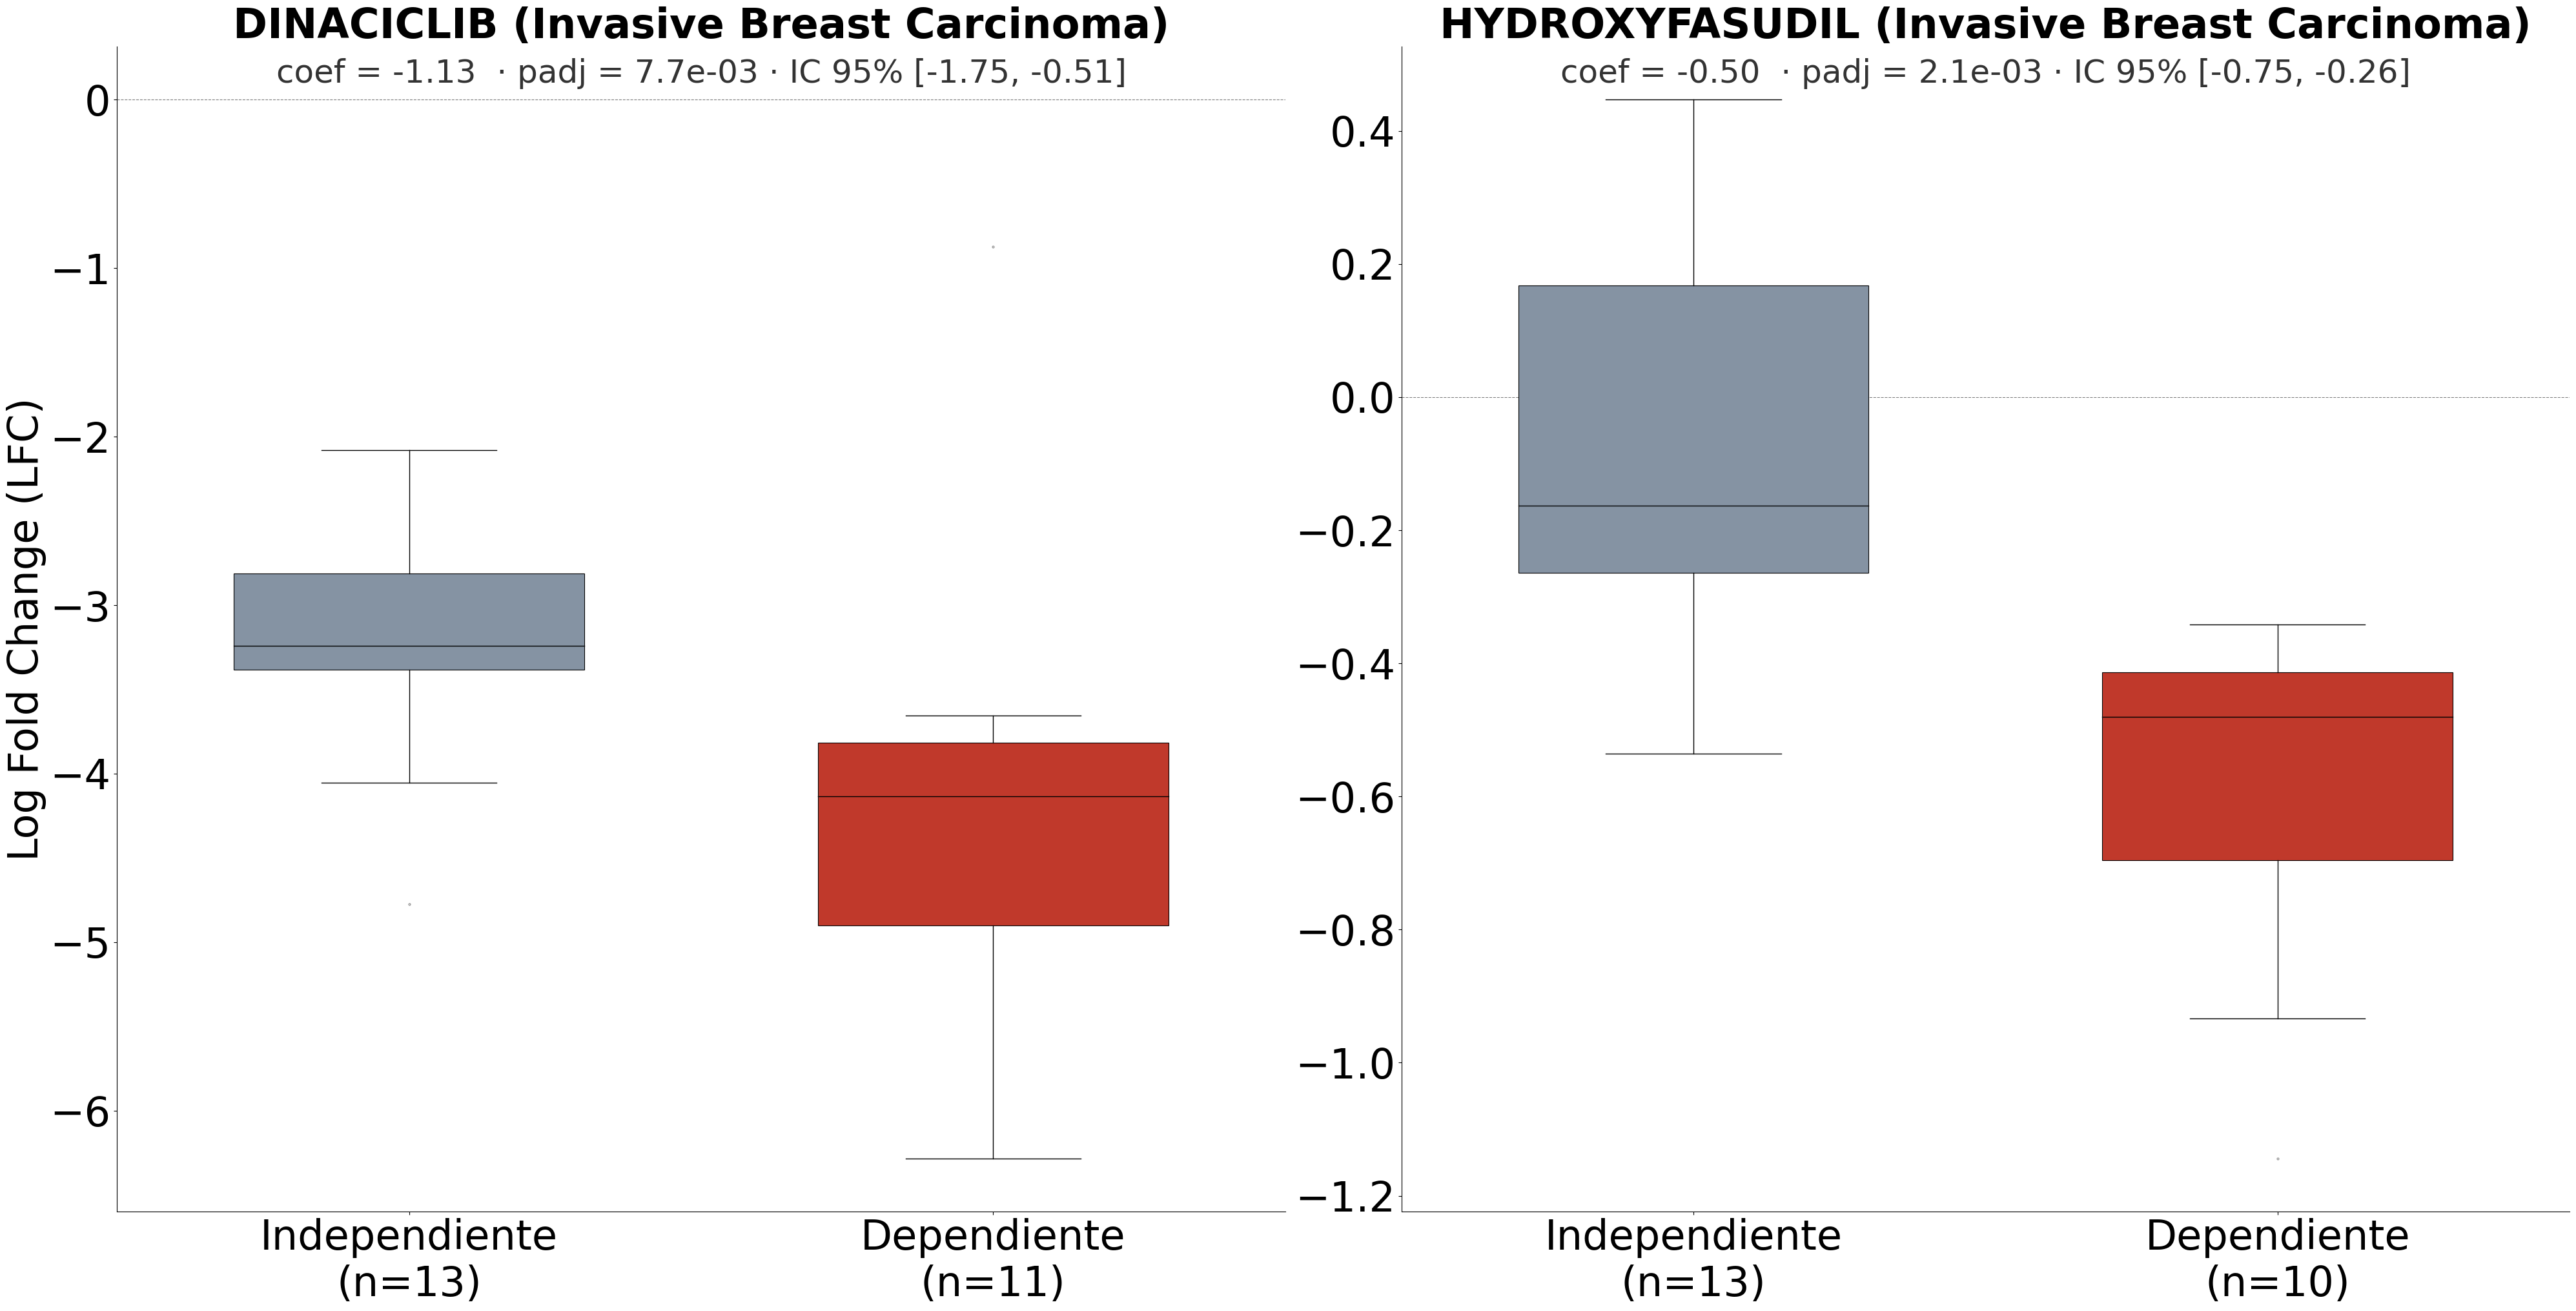

In [18]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

n = len(candidatas)
fig, axes = plt.subplots(1, n, figsize=(20* n, 24), squeeze=False)
axes = axes[0]
fig.subplots_adjust(top=0.85)
for ax, (_, row) in zip(axes, candidatas.iterrows()):
    # Reconstruir datos de la droga para este subtipo
    brd_ids = data[data['Drug.Name.clean'] == limpiar_nombre(row['Drug.Name'])]['BRD_ID'].tolist()
    df_droga = data[data['BRD_ID'].isin(brd_ids)].copy()
    df_droga['yap_dep'] = df_droga['depmap_id'].isin(
        lineas_cel_yap_dependent['ModelID']
    ).astype(int)
    df_droga = df_droga.merge(
        cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
        left_on='depmap_id', right_on='ModelID', how='inner'
    )
    df_droga = df_droga[df_droga['OncotreePrimaryDisease'] == row['subtipo']]
    df_droga = df_droga.dropna(subset=['LFC'])

    lfc_nodep = df_droga[df_droga['yap_dep'] == 0]['LFC'].values
    lfc_dep = df_droga[df_droga['yap_dep'] == 1]['LFC'].values

    bp = ax.boxplot(
        [lfc_nodep, lfc_dep],
        positions=[1, 2],
        widths=0.6,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        flierprops=dict(marker='o', markersize=2, alpha=0.4),
    )

    colores = ['#8593a3', '#c0392b']
    for parche, c in zip(bp['boxes'], colores):
        parche.set_facecolor(c)
        parche.set_edgecolor('black')
        parche.set_linewidth(0.8)

    ax.axhline(0, ls='--', color='gray', linewidth=0.8, zorder=0)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        [f"Independiente\n(n={row['n_nodep']})",
         f"Dependiente\n(n={row['n_dep']})"],
        fontsize=46
    )
    ax.tick_params(axis='y', labelsize=46)
    ax.set_title(f"{row['Drug.Name']} ({row['subtipo']})", fontsize=46, fontweight='bold')
    ax.text(0.5, 0.99,
        f"coef = {row['coef']:.2f}  · padj = {row['padj']:.1e} · IC 95% [{row['ci_low']:.2f}, {row['ci_high']:.2f}]", 
        transform=ax.transAxes, ha='center', va='top',
        fontsize=36, color='#333333')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Log Fold Change (LFC)', fontsize=46)
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig("/home/miguel-agromayor-otero/Escritorio/TFM_datos/Graficos/candidatas.pdf", bbox_inches='tight')